#SET UP AND DATA IMPORT


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

from kagglehub import KaggleDatasetAdapter

pd.set_option('display.max_columns', 30)

In [ ]:
# !pip install opendatasets

In [ ]:
# # Ini langsung ke github, harus generate key masing" dari github masing"
# import opendatasets as od
# od.download('https://www.kaggle.com/datasets/iamsouravbanerjee/heart-attack-prediction-dataset/data')

In [ ]:
# Set the path to the file you'd like to load
file_path = "heart_attack_prediction_dataset.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "iamsouravbanerjee/heart-attack-prediction-dataset",
  file_path,
)

/tmp/ipykernel_3150/4136929747.py:5: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


100%|██████████| 519k/519k [00:00<00:00, 716kB/s]

Extracting zip of heart_attack_prediction_dataset.csv...


In [ ]:
# df = pd.read_csv('/content/heart-attack-prediction-dataset/heart_attack_prediction_dataset.csv')
df.head()

,Patient ID,Age,Sex,Cholesterol,Blood Pressure,Heart Rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,Diet,Previous Heart Problems,Medication Use,Stress Level,Sedentary Hours Per Day,Income,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Country,Continent,Hemisphere,Heart Attack Risk
0,BMW7812,67,Male,208,158/88,72,0,0,1,0,0,4.168189,Average,0,0,9,6.615001,261404,31.251233,286,0,6,Argentina,South America,Southern Hemisphere,0
1,CZE1114,21,Male,389,165/93,98,1,1,1,1,1,1.813242,Unhealthy,1,0,1,4.963459,285768,27.194973,235,1,7,Canada,North America,Northern Hemisphere,0
2,BNI9906,21,Female,324,174/99,72,1,0,0,0,0,2.078353,Healthy,1,1,9,9.463426,235282,28.176571,587,4,4,France,Europe,Northern Hemisphere,0
3,JLN3497,84,Male,383,163/100,73,1,1,1,0,1,9.828130,Average,1,0,9,7.648981,125640,36.464704,378,3,4,Canada,North America,Northern Hemisphere,0
4,GFO8847,66,Male,318,91/88,93,1,1,1,1,0,5.804299,Unhealthy,1,0,6,1.514821,160555,21.809144,231,1,5,Thailand,Asia,Northern Hemisphere,0


#**1. EXPLANATORY DATA ANALYSIS**

## 1.1 Data Assesment

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 26 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Patient ID                       8763 non-null   object 
 1   Age                              8763 non-null   int64  
 2   Sex                              8763 non-null   object 
 3   Cholesterol                      8763 non-null   int64  
 4   Blood Pressure                   8763 non-null   object 
 5   Heart Rate                       8763 non-null   int64  
 6   Diabetes                         8763 non-null   int64  
 7   Family History                   8763 non-null   int64  
 8   Smoking                          8763 non-null   int64  
 9   Obesity                          8763 non-null   int64  
 10  Alcohol Consumption              8763 non-null   int64  
 11  Exercise Hours Per Week          8763 non-null   float64
 12  Diet                

In [ ]:
df.columns

Index(['Patient ID', 'Age', 'Sex', 'Cholesterol', 'Blood Pressure',
       'Heart Rate', 'Diabetes', 'Family History', 'Smoking', 'Obesity',
       'Alcohol Consumption', 'Exercise Hours Per Week', 'Diet',
       'Previous Heart Problems', 'Medication Use', 'Stress Level',
       'Sedentary Hours Per Day', 'Income', 'BMI', 'Triglycerides',
       'Physical Activity Days Per Week', 'Sleep Hours Per Day', 'Country',
       'Continent', 'Hemisphere', 'Heart Attack Risk'],
      dtype='object')

In [ ]:
df.duplicated().sum()

np.int64(0)

Dataset berisi 8.763 data pasien dari berbagai negara dengan 26 fitur klinis dan demografis.
Tidak ditemukan missing values maupun data duplikat, kualitas data bersih dan siap dianalisis.
Blood Pressure disimpan dalam format string "Systolic/Diastolic" perlu dipisah menjadi dua fitur numerik agar bisa diproses secara kuantitatif.

## 1.2 Feature Encoding and Stratification

In [ ]:
# Membuat kolom sex menjadi numeric menggunakan dummies
separate_sex = pd.get_dummies(df['Sex'], prefix='Sex', dtype=int)
df_new = pd.concat([df.iloc[:, :2], separate_sex, df.iloc[:, 2:]], axis=1)
df_new = df.drop(columns=['Sex'])

In [ ]:
# Memisahkan nilai Blood Pressure menjadi 2 kolom yaitu Systolic dan Diastolic
separate_bp = df['Blood Pressure'].str.split('/', expand=True).astype(int)
separate_bp.columns = ['Systolic', 'Diastolic']
df = pd.concat([df.iloc[:, :5], separate_bp, df.iloc[:, 5:]], axis=1)
df = df.drop(columns=['Blood Pressure'])

In [ ]:
# Categorical Feature - (ordinal dan nominal)

categorical = [
    'Sex',
    'Diabetes',
    'Family History',
    'Smoking',
    'Obesity',
    'Alcohol Consumption',
    'Diet',
    'Previous Heart Problems',
    'Medication Use',
    'Stress Level',
    'Sleep Hours Per Day',
    'Physical Activity Days Per Week',
    'Country',
    'Continent',
    'Hemisphere',
    'Heart Attack Risk'
]
print(f"shape data : {df[categorical].shape}")

df[categorical].head()

shape data : (8763, 16)


,Sex,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,Diet,Previous Heart Problems,Medication Use,Stress Level,Sleep Hours Per Day,Physical Activity Days Per Week,Country,Continent,Hemisphere,Heart Attack Risk
0,Male,0,0,1,0,0,Average,0,0,9,6,0,Argentina,South America,Southern Hemisphere,0
1,Male,1,1,1,1,1,Unhealthy,1,0,1,7,1,Canada,North America,Northern Hemisphere,0
2,Female,1,0,0,0,0,Healthy,1,1,9,4,4,France,Europe,Northern Hemisphere,0
3,Male,1,1,1,0,1,Average,1,0,9,4,3,Canada,North America,Northern Hemisphere,0
4,Male,1,1,1,1,0,Unhealthy,1,0,6,5,1,Thailand,Asia,Northern Hemisphere,0


In [ ]:
# Numerical Feature

numerical = [col for col in df.columns if col not in categorical and col != 'Patient ID']
print(f"shape data : {df[numerical].shape}")
print(numerical)

df[numerical].head()

shape data : (8763, 10)
['Age', 'Cholesterol', 'Systolic', 'Diastolic', 'Heart Rate', 'Exercise Hours Per Week', 'Sedentary Hours Per Day', 'Income', 'BMI', 'Triglycerides']


,Age,Cholesterol,Systolic,Diastolic,Heart Rate,Exercise Hours Per Week,Sedentary Hours Per Day,Income,BMI,Triglycerides
0,67,208,158,88,72,4.168189,6.615001,261404,31.251233,286
1,21,389,165,93,98,1.813242,4.963459,285768,27.194973,235
2,21,324,174,99,72,2.078353,9.463426,235282,28.176571,587
3,84,383,163,100,73,9.828130,7.648981,125640,36.464704,378
4,66,318,91,88,93,5.804299,1.514821,160555,21.809144,231


## 1.3 Univariate Analysis

In [ ]:
# imbalance dataset pada target
df['Heart Attack Risk'].value_counts(normalize=True)

,proportion
Heart Attack Risk,
0,0.641789
1,0.358211


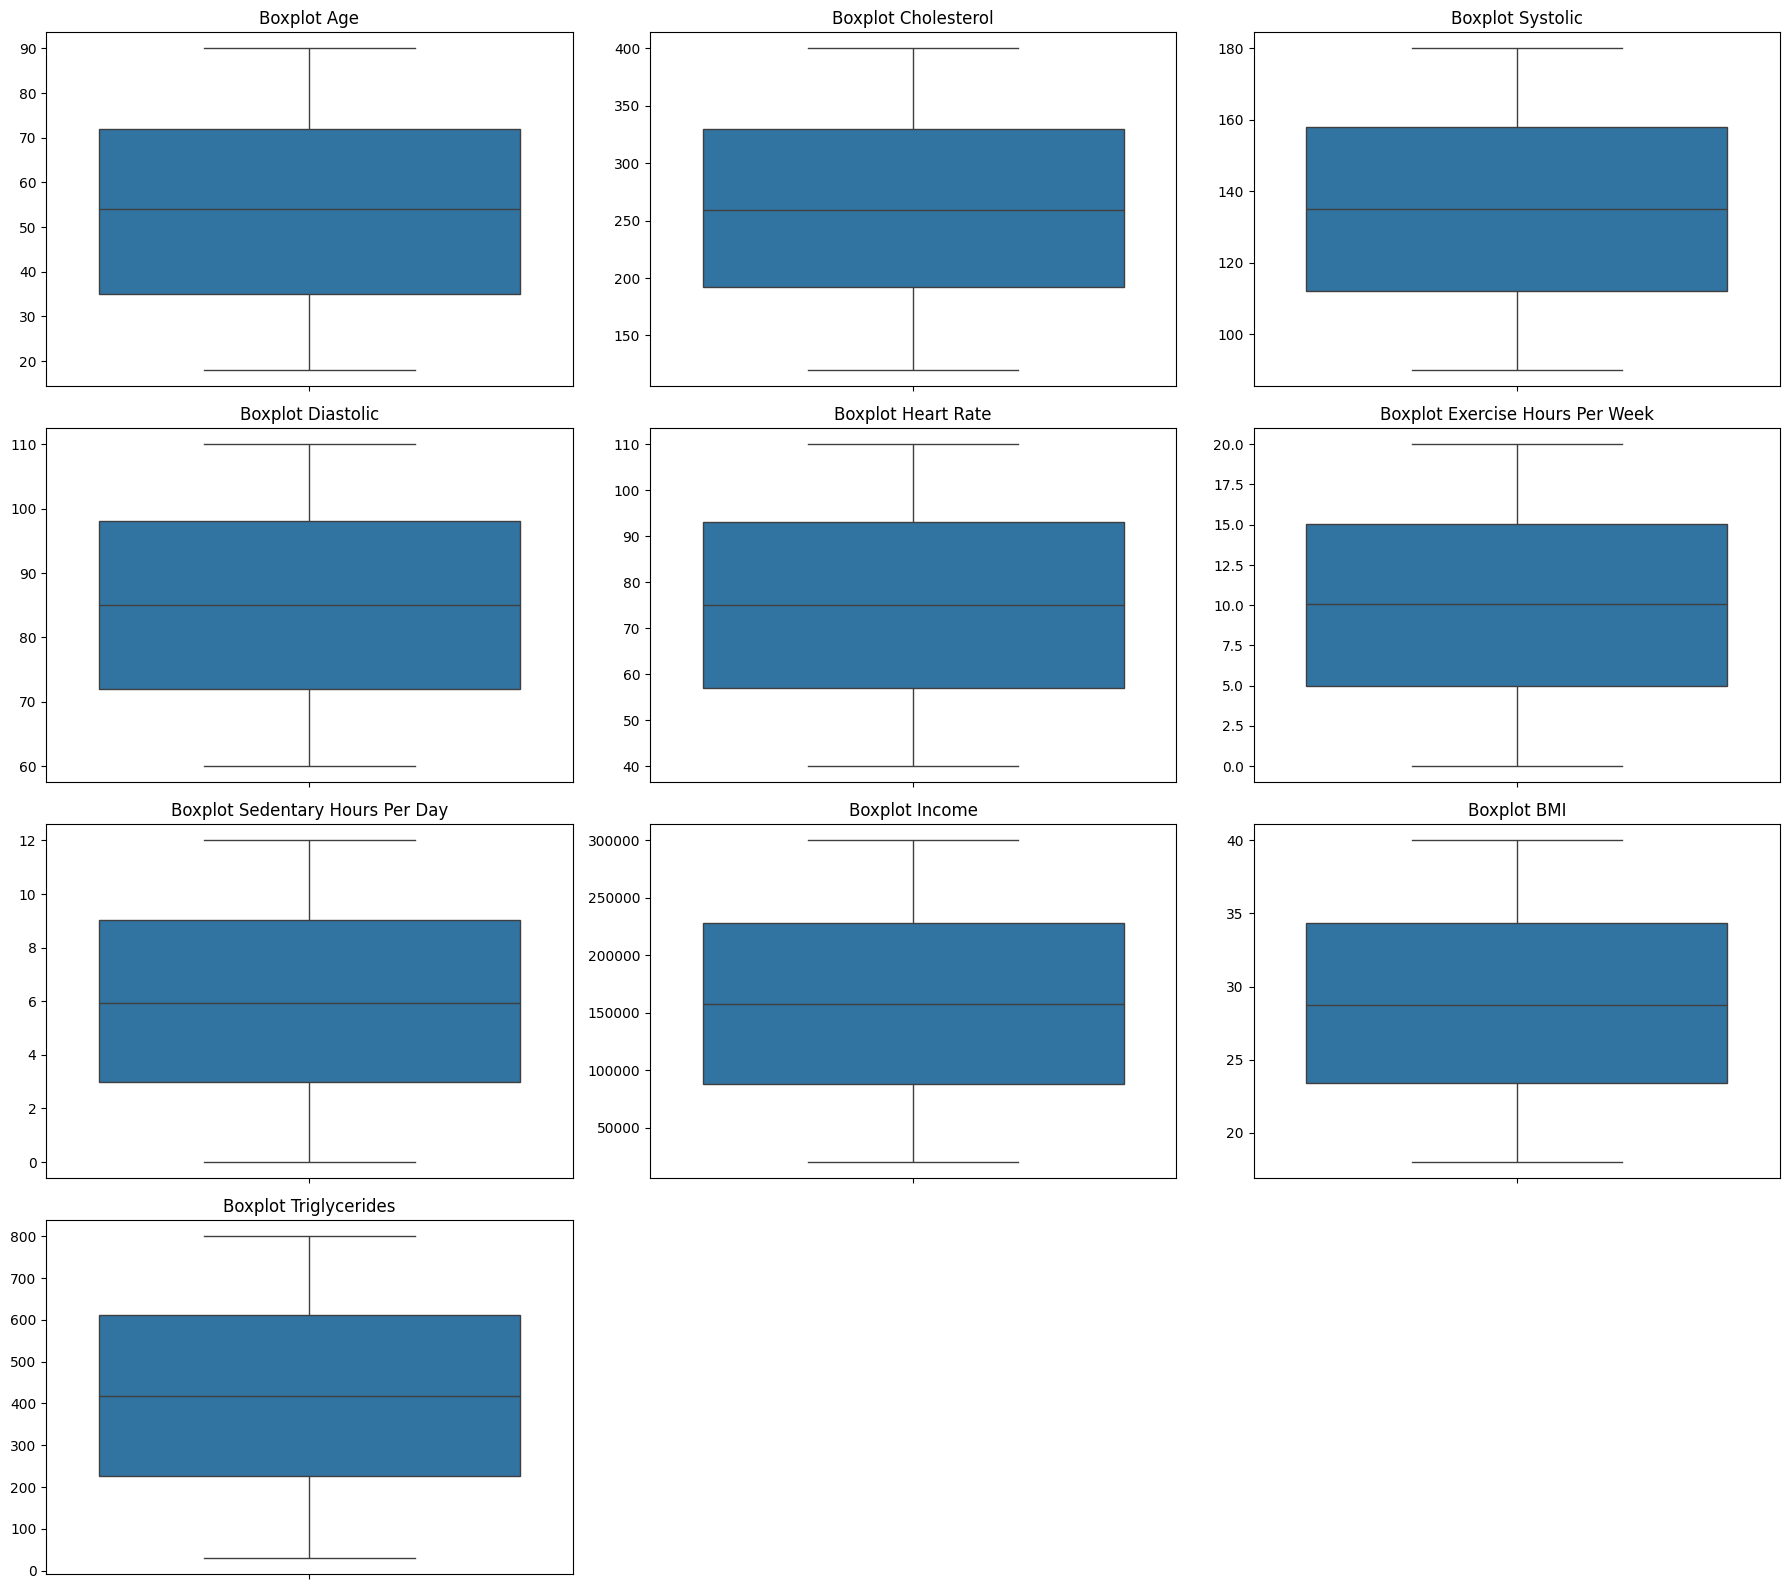

In [ ]:
# Cek outlier pada numerical feature

# Menghitung jumlah kolom agar penataan subplot otomatis
num_cols = len(numerical)
nrows = (num_cols + 3) // 3  # Membuat grid dengan 3 kolom per baris

plt.figure(figsize=(18, nrows * 4))

for i, col in enumerate(numerical):
    plt.subplot(nrows, 3, i + 1)
    sns.boxplot(data=df, y=col)
    plt.title(f'Boxplot {col}', fontsize=12)
    plt.ylabel('')

plt.tight_layout()
plt.show()

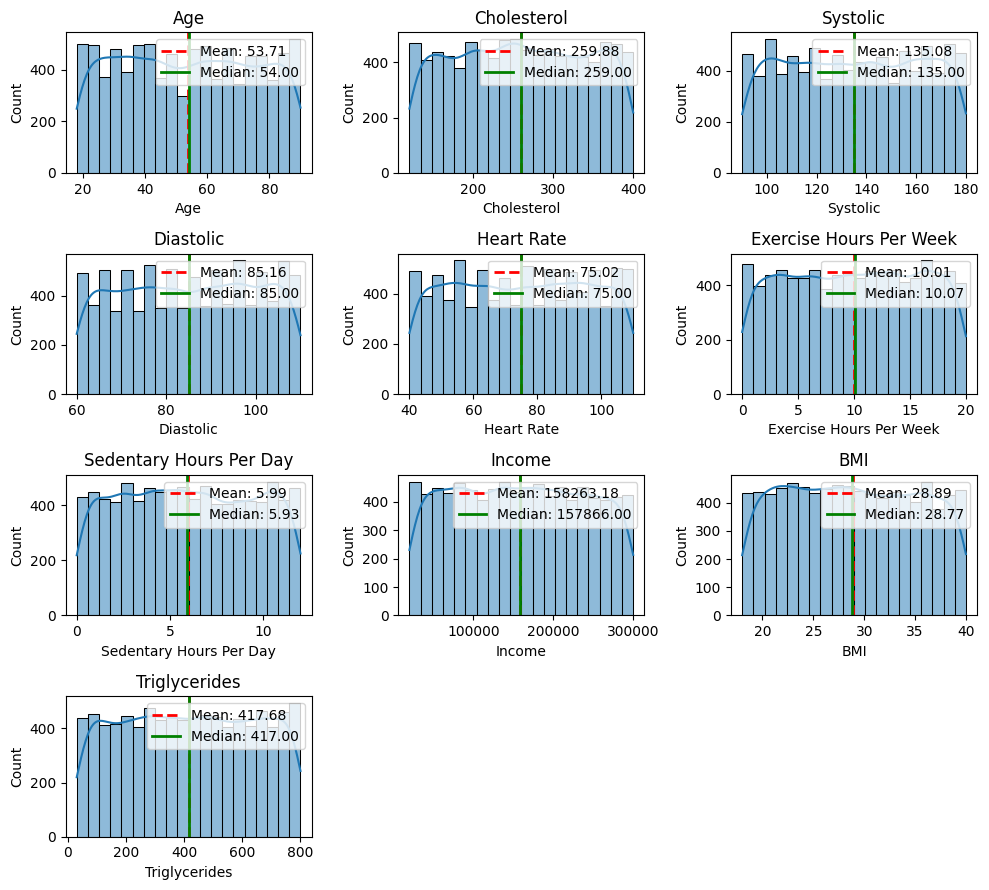

In [ ]:
# Melihat distribusi pada numerical feature

# Mengatur susunan grid subplot (misal: 4 baris, 3 kolom)
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(10, 9))
axes = axes.flatten()  # Meratakan matriks indeks agar mudah di-loop

for i, col in enumerate(numerical):
    # 1. Plot Distribusi (Kombinasi Histogram dan KDE Line)
    sns.histplot(data=df, x=col, kde=True, ax=axes[i], edgecolor='black', bins=20)

    # Hitung nilai mean dan median
    mean_val = df[col].mean()
    median_val = df[col].median()

    # 2. Tambahkan Garis Vertikal untuk Mean dan Median
    axes[i].axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
    axes[i].axvline(median_val, color='green', linestyle='-', linewidth=2, label=f'Median: {median_val:.2f}')

    # Pengaturan properti grafik
    axes[i].set_title(f'{col}', fontsize=12)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].legend(loc='upper right')  # Menampilkan legenda mean & median

# Menghapus sisa subplots yang tidak terpakai jika jumlah kolom ganjil
for j in range(len(numerical), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# tambahin syntax buat cek normalitas biar analisis secara kuantitatif

Dari keseluruhan data +/- 64% pasien tidak berisiko (label 0) dan 36% berisiko terkena serangan jantung (label 1). Ini menunjukkan adanya class imbalance ringan — tidak ekstrem, namun Ttetap perlu diperhatikan saat proses training.

Dari visualisasi boxplot pada semua fitur numerik, tidak ditemukan outlier ekstrem yang perlu dihapus. data dapat langsung dilanjutkan ke tahap preprocessing.

distribusi fitur numerik:
- Usia (Age): Distribusi cukup merata dari 18 hingga 90+ tahun, dataset berbagai kelompok umur representatif.
- Kolesterol & Trigliserida: Distribusi right-skewed — sebagian pasien
  dengan kadar yang sangat tinggi, ada korelasi dengan risiko kardiovaskular.
- Exercise Hours Per Week & Sedentary Hours Per Day: Kedua fitur ada di ujung yang berlawanan — perlu dites keduanya saling berpengaruh terhadap risiko atau tidak.
- BMI: Distribusi mendekati normal, mencerminkan variasi berat badan yang realistis pada populasi global.

## 1.4 Bivariate Analysis

In [ ]:
# Visualisasi Bar Chart untuk mengetahui yang berisiko terkena Heart Attack
def group_barchart (column):
  risk = df.groupby(['Heart Attack Risk', column]).count()['Patient ID'].reset_index()

  z = sns.catplot(
      data = risk, kind = 'bar',
      x = 'Heart Attack Risk', y = 'Patient ID', hue = column,
      palette='dark', height = 4
  )

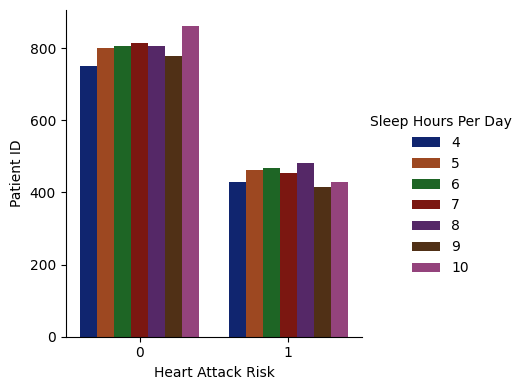

In [ ]:
group_barchart('Sleep Hours Per Day')

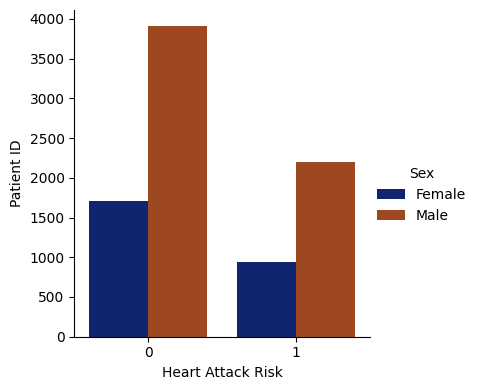

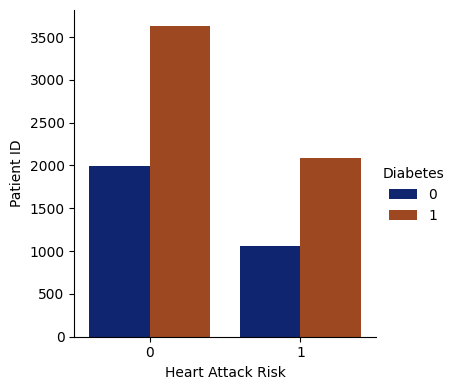

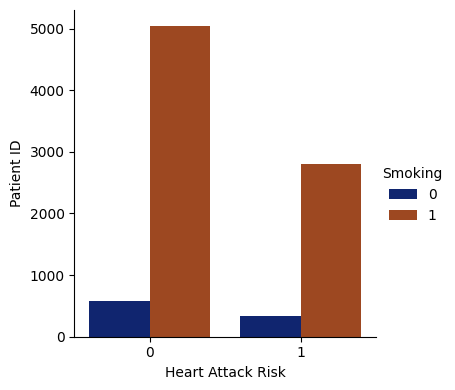

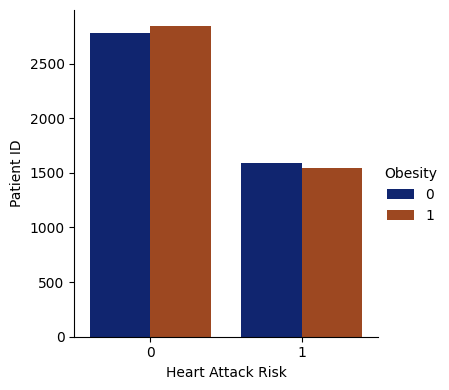

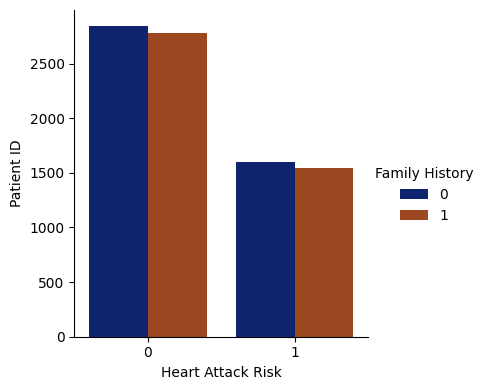

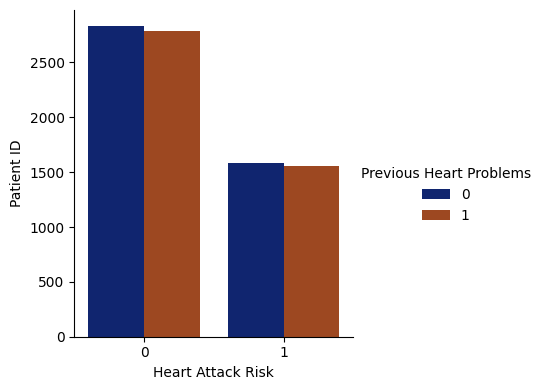

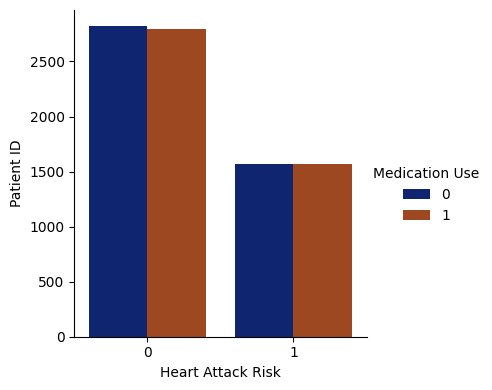

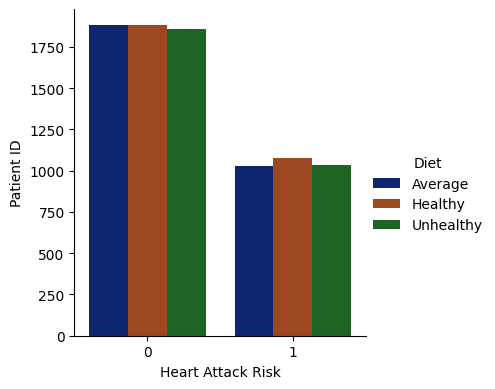

In [ ]:
for col in ['Sex', 'Diabetes', 'Smoking', 'Obesity', 'Family History',
            'Previous Heart Problems', 'Medication Use', 'Diet']:
    group_barchart(col)

Analisa visualisasi bar chart tiap fitur terhadap risiko serangan jantung:
- Jenis Kelamin (Sex): jumlah kasus berisiko Pria lebih tinggi dibanding wanita.
- Riwayat Keluarga (Family History): Pasien dengan riwayat keluarga terkena penyakit jantung cenderung lebih berisiko
- Diabetes: Pasien dengan diabetes punya proporsi risiko serangan jantung yang lebih tinggi.
- Merokok (Smoking): Perokok mendominasi kelompok berisiko.
- Previous Heart Problems: Pasien yang pernah mengalami masalah jantung sebelumnya memiliki risiko yang jauh lebih tinggi.
- Obesitas: Pasien dengan obesitas kecenderungan risiko yang lebih tinggi.
- Diet: Diet "Unhealthy" berkorelasi dengan lebih banyak kasus berisiko dibanding diet "Healthy". kelompok "Average" berada di tengah indikasik pola makan memiliki pengaruh terhadap kesehatan jantung.
- Medication Use: Penggunaan obat tidak menurunkan risiko secara signifikan.

Yang beresiko terkena Heart Attack berdasarkan waktu tidur per hari bila diurutkan dari yang paling terkena dampaknya adalah:
1. 8 jam
2. 6 jam
3. 5 jam
4. 7 jam
5. 5 jam
6. 10 jam
7. 9 jam

Resiko Heart Attack bila dilihat dari umur, paling banyak di umur 20, 60, dan 90

<Axes: xlabel='Heart Attack Risk', ylabel='Age'>

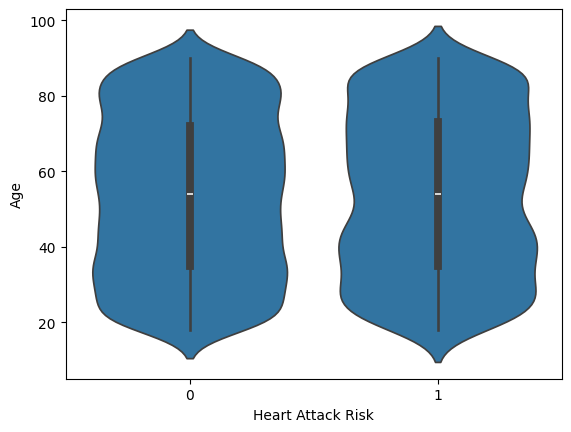

In [ ]:
sns.violinplot(data=df, x='Heart Attack Risk', y='Age')

Dari violin risiko serangan jantung tersebar merata di semua kelompok usia tidak hanya didominasi lansia. Distribusi lebar pada kedua kelas menunjukkan bahwa usia tidak cukup memprediksi risiko jadi perlu kombinasi dengan faktor lain.

## 1.4 Multivariate Analysis

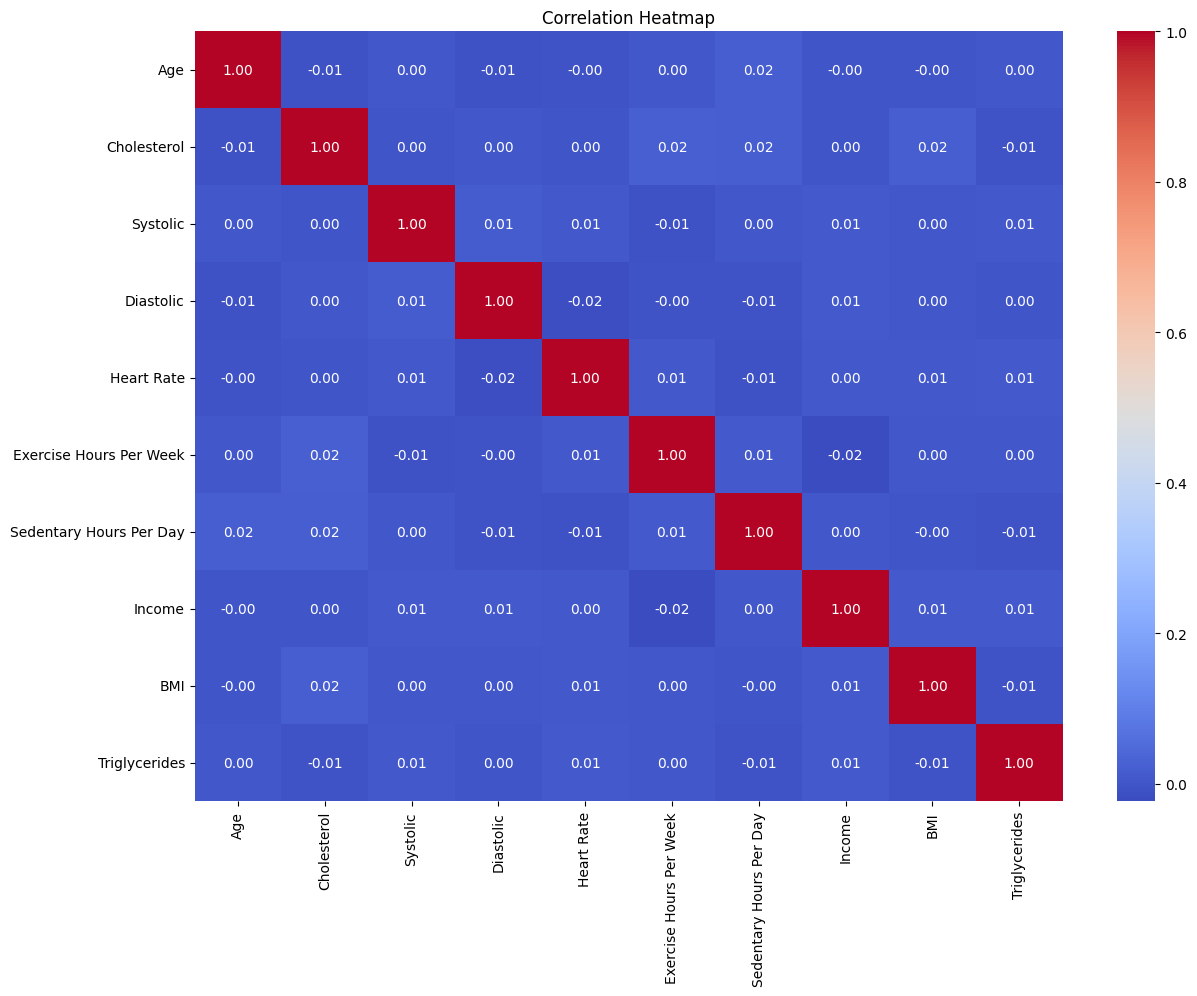

In [ ]:
df_numeric = df[numerical]

plt.figure(figsize=(14, 10))
sns.heatmap(df_numeric.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

- Tidak ada korelasi yang sangat tinggi (> 0.8) antar fitur numerik, artinya
  tidak ada multicollinearity ekstrem yang perlu dihapus.

- Heart Attack Risk menunjukkan korelasi yang relatif rendah terhadap fitur-fitur numerik secara individual. Tidak ada satu yang dominan jadi perlu kombinasi banyak fitur.

- Sedentary Hours Per Day dan Exercise Hours Per Week menunjukkan korelasi
  negatif (semakin banyak olahraga, semakin sedikit waktu tidak aktif).


## 1.5 Kesimpulan EDA


1. **Data bersih** : tidak ada missing values atau duplikat yang perlu ditangani
2. **Class imbalance ringan** (64:36) : perlu dipertimbangkan strategi seperti
   class_weight atau SMOTE saat training
3. **Blood Pressure** berhasil dipisah menjadi Systolic dan Diastolic : lebih informatif
4. **Tidak ada outlier ekstrem** : scaling standar sudah cukup
5. **Fitur paling berpengaruh** terhadap risiko berdasarkan analisis bivariat:
   - Previous Heart Problems
   - Family History
   - Smoking
   - Diabetes
   - Obesity

#**2. DATA PRE-PROCESSING**

**KALAU UDAH OKE DI HAPUS**

Things to add:
Tugas pre processing:
1. Ngebersihin data yang
duplikat, kosong (tapi data kita gaada) - Data Cleaning
2. Kalo ada distribusi data yang ga normal skew nya itu dibenerin (perlu liat distribusi data di atas), dibenerin ada syntaxnya - Feature Engineering
3. Kalo datasetnya imbalance itu perlu di proses dulu agar siap training (SMOTE for imbalanced data)

##2.1 Set-up dan Load Data

**Step a. Setup & Load Data Fresh**

Dataset di-load ulang dari awal (fresh copy), terpisah dari data yang sudah dimodifikasi di bagian EDA agar tidak ada "kontaminasi" dari perubahan sementara yang dibuat selama eksplorasi. Pre-processing harus dimulai dari data yang bersih dan konsisten.

**Step b. Split Blood Pressure**

Kolom Blood Pressure yang berformat string "120/80" dipecah menjadi dua kolom numerik terpisah — Systolic (tekanan saat jantung memompa) dan Diastolic (tekanan saat jantung beristirahat). Model machine learning tidak bisa membaca string. Dengan memisahkannya, kedua nilai tekanan darah bisa dianalisis secara kuantitatif dan digunakan sebagai fitur numerik independen.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

#step a. Load ulang data fresh
file_path = "heart_attack_prediction_dataset.csv"
df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "iamsouravbanerjee/heart-attack-prediction-dataset",
    file_path,
)

#step Split Blood Pressure
separate_bp = df['Blood Pressure'].str.split('/', expand=True).astype(int)
separate_bp.columns = ['Systolic', 'Diastolic']
df = pd.concat([df.iloc[:, :5], separate_bp, df.iloc[:, 5:]], axis=1)
df = df.drop(columns=['Blood Pressure'])

print("Shape awal:", df.shape)
print("Kolom:", df.columns.tolist())
df.head(3)

/tmp/ipykernel_3150/3652467862.py:8: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'heart-attack-prediction-dataset' dataset.
Shape awal: (8763, 27)
Kolom: ['Patient ID', 'Age', 'Sex', 'Cholesterol', 'Systolic', 'Diastolic', 'Heart Rate', 'Diabetes', 'Family History', 'Smoking', 'Obesity', 'Alcohol Consumption', 'Exercise Hours Per Week', 'Diet', 'Previous Heart Problems', 'Medication Use', 'Stress Level', 'Sedentary Hours Per Day', 'Income', 'BMI', 'Triglycerides', 'Physical Activity Days Per Week', 'Sleep Hours Per Day', 'Country', 'Continent', 'Hemisphere', 'Heart Attack Risk']


,Patient ID,Age,Sex,Cholesterol,Systolic,Diastolic,Heart Rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,Diet,Previous Heart Problems,Medication Use,Stress Level,Sedentary Hours Per Day,Income,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Country,Continent,Hemisphere,Heart Attack Risk
0,BMW7812,67,Male,208,158,88,72,0,0,1,0,0,4.168189,Average,0,0,9,6.615001,261404,31.251233,286,0,6,Argentina,South America,Southern Hemisphere,0
1,CZE1114,21,Male,389,165,93,98,1,1,1,1,1,1.813242,Unhealthy,1,0,1,4.963459,285768,27.194973,235,1,7,Canada,North America,Northern Hemisphere,0
2,BNI9906,21,Female,324,174,99,72,1,0,0,0,0,2.078353,Healthy,1,1,9,9.463426,235282,28.176571,587,4,4,France,Europe,Northern Hemisphere,0


##2.2 Drop Kolom

**Drop Kolom Tidak Relevan**

Empat kolom yang dihapus dari dataset.
- Patient ID	: Hanya identifier unik, bukan fitur klinis — tidak ada informasi prediktif
- Country	: Terlalu banyak kategori (20+ negara), akan jadi noise
- Continent :	Informasi geografis tidak relevan untuk prediksi risiko medis individu
- Hemisphere : Terlalu general, tidak ada hubungan kausal dengan risiko jantung

In [ ]:
cols_to_drop = ['Patient ID', 'Country', 'Continent', 'Hemisphere']

df = df.drop(columns=cols_to_drop)

print("Shape setelah drop:", df.shape)
print("Kolom tersisa:", df.columns.tolist())

Shape setelah drop: (8763, 23)
Kolom tersisa: ['Age', 'Sex', 'Cholesterol', 'Systolic', 'Diastolic', 'Heart Rate', 'Diabetes', 'Family History', 'Smoking', 'Obesity', 'Alcohol Consumption', 'Exercise Hours Per Week', 'Diet', 'Previous Heart Problems', 'Medication Use', 'Stress Level', 'Sedentary Hours Per Day', 'Income', 'BMI', 'Triglycerides', 'Physical Activity Days Per Week', 'Sleep Hours Per Day', 'Heart Attack Risk']


##2.3 Korelasi biserial

**Uji Korelasi Point Biserial Mengukur seberapa kuat hubungan antara setiap fitur biner (0/1) terhadap target Heart Attack Risk.**

Jika p-value < 0.05, berarti korelasinya signifikan secara statistik. Feature validation — memastikan fitur yang kita masukkan ke model benar-benar memiliki hubungan yang bermakna dengan target, bukan hanya kebetulan. Fitur yang tidak signifikan bisa meningkatkan noise dalam model.

In [ ]:
from scipy.stats import pointbiserialr
import matplotlib.pyplot as plt
import pandas as pd

# Kolom kategorik biner yang mau dicek korelasi vs Heart Attack Risk
cat_cols = ['Diabetes', 'Family History', 'Smoking', 'Obesity',
            'Alcohol Consumption', 'Previous Heart Problems',
            'Medication Use']

results_biserial = []
for col in cat_cols:
    corr, pval = pointbiserialr(df[col], df['Heart Attack Risk'])
    results_biserial.append({'Feature': col,
                              'Correlation': round(corr, 4),
                              'P-Value': round(pval, 4),
                              'Signifikan': '✓' if pval < 0.05 else '✗'})

df_biserial = pd.DataFrame(results_biserial).sort_values('Correlation',
               key=lambda x: x.abs(), ascending=False)
print(df_biserial.to_string(index=False))

                Feature  Correlation  P-Value Signifikan
               Diabetes       0.0172   0.1069          ✗
    Alcohol Consumption      -0.0138   0.1972          ✗
                Obesity      -0.0133   0.2126          ✗
                Smoking      -0.0041   0.7045          ✗
         Medication Use       0.0022   0.8343          ✗
         Family History      -0.0017   0.8771          ✗
Previous Heart Problems       0.0003   0.9796          ✗


##2.4 Encode Fitur Kategorikal


**KALAU UDAH OKE DI HAPUS**

1. pastiin encoding buat semua data, tambahin mana nominal mana ordinal
2. data Y dengan SMOTE

**Mengubah fitur teks menjadi angka agar bisa dibaca model.**

- Sex	: Tipe Nominal dengan metode Binary (0/1).	agar tidak ada urutan — Male bukan "lebih besar" dari Female
- Diet : Tipe	Ordinal	dengan metode Angka berurutan (0–2).	agar ada hierarki nilai: Healthy > Average > Unhealthy

Fitur biner lain (Diabetes, Smoking, dll.) sudah bernilai 0/1 sejak awal, sehingga tidak perlu di-encode lagi.


In [ ]:
# Binary Encoding: Sex
df['Sex'] = df['Sex'].map({'Male': 1, 'Female': 0})

# Ordinal Encoding: Diet
diet_order = {'Healthy': 2, 'Average': 1, 'Unhealthy': 0}
df['Diet'] = df['Diet'].map(diet_order)

# Verifikasi hasil encoding
print("Unique values Sex   :", df['Sex'].unique())
print("Unique values Diet  :", df['Diet'].unique())
print("\nCek tipe data setelah encoding:")
print(df[['Sex', 'Diet']].dtypes)
print("\nCek tidak ada NaN setelah mapping:")
print(df[['Sex', 'Diet']].isnull().sum())

df.head(3)

Unique values Sex   : [1 0]
Unique values Diet  : [1 0 2]

Cek tipe data setelah encoding:
Sex     int64
Diet    int64
dtype: object

Cek tidak ada NaN setelah mapping:
Sex     0
Diet    0
dtype: int64


,Age,Sex,Cholesterol,Systolic,Diastolic,Heart Rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,Diet,Previous Heart Problems,Medication Use,Stress Level,Sedentary Hours Per Day,Income,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Heart Attack Risk
0,67,1,208,158,88,72,0,0,1,0,0,4.168189,1,0,0,9,6.615001,261404,31.251233,286,0,6,0
1,21,1,389,165,93,98,1,1,1,1,1,1.813242,0,1,0,1,4.963459,285768,27.194973,235,1,7,0
2,21,0,324,174,99,72,1,0,0,0,0,2.078353,2,1,1,9,9.463426,235282,28.176571,587,4,4,0


##2.5 Pisah Fitur (X) dan Target (y)


**Memisahkan dataset menjadi fitur input (X) dan label target (y).**

X berisi semua kolom fitur yang akan digunakan model untuk belajar, sedangkan y berisi kolom Heart Attack Risk yang ingin diprediksi. Keduanya harus terpisah agar tidak terjadi data leakage — model tidak boleh "melihat" jawaban saat proses training.

In [ ]:
# Target
y = df['Heart Attack Risk']

# Fitur
X = df.drop(columns=['Heart Attack Risk'])

print("Shape X (fitur) :", X.shape)
print("Shape y (target):", y.shape)
print("\nDistribusi target:")
print(y.value_counts())
print("\nKolom fitur yang akan dipakai:")
print(X.columns.tolist())

Shape X (fitur) : (8763, 22)
Shape y (target): (8763,)

Distribusi target:
Heart Attack Risk
0    5624
1    3139
Name: count, dtype: int64

Kolom fitur yang akan dipakai:
['Age', 'Sex', 'Cholesterol', 'Systolic', 'Diastolic', 'Heart Rate', 'Diabetes', 'Family History', 'Smoking', 'Obesity', 'Alcohol Consumption', 'Exercise Hours Per Week', 'Diet', 'Previous Heart Problems', 'Medication Use', 'Stress Level', 'Sedentary Hours Per Day', 'Income', 'BMI', 'Triglycerides', 'Physical Activity Days Per Week', 'Sleep Hours Per Day']


##2.6 Train-Test Split (80:20)

**Data dibagi menjadi 80% untuk melatih model dan 20% untuk menguji performa model pada data yang belum pernah dilihat.**

`stratify=y`: Memastikan proporsi kelas (64% tidak berisiko : 36% berisiko) sama persis di training set maupun test set. Tanpa ini, bisa saja test set kebetulan hanya berisi pasien tidak berisiko sehingga evaluasinya tidak valid.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train distribusi:\n", y_train.value_counts(normalize=True).round(3))
print("y_test  distribusi:\n", y_test.value_counts(normalize=True).round(3))

X_train: (7010, 22)
X_test : (1753, 22)
y_train distribusi:
 Heart Attack Risk
0    0.642
1    0.358
Name: proportion, dtype: float64
y_test  distribusi:
 Heart Attack Risk
0    0.642
1    0.358
Name: proportion, dtype: float64


##2.7 Feature Scaling

**Fitur numerik kontinu distandarisasi sehingga memiliki mean = 0 dan standar deviasi = 1.**

Fitur memiliki satuan yang sangat berbeda — Age berkisar 18–90, Income bisa jutaan, BMI 15–40. Tanpa scaling, model seperti SVM dan Logistic Regression akan bias ke fitur bernilai besar karena jaraknya lebih dominan secara matematis.

Aturan penting — fit HANYA di training data:
- `.fit_transform()` di X_train → scaler belajar mean & std dari training data
- `.transform()` saja di X_test → test data di-scale pakai parameter yang sama

Jika scaler di-fit di test data juga, itu disebut **data leakage** — model secara tidak langsung "melihat" informasi dari test set saat training.

In [ ]:
from sklearn.preprocessing import StandardScaler

cols_to_scale = [
    'Age', 'Cholesterol', 'Systolic', 'Diastolic', 'Heart Rate',
    'Exercise Hours Per Week', 'Sedentary Hours Per Day',
    'Income', 'BMI', 'Triglycerides'
]

scaler = StandardScaler()
X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test[cols_to_scale]  = scaler.transform(X_test[cols_to_scale])

print("Sample X_train setelah scaling:")
X_train[cols_to_scale].describe().round(2)

Sample X_train setelah scaling:


,Age,Cholesterol,Systolic,Diastolic,Heart Rate,Exercise Hours Per Week,Sedentary Hours Per Day,Income,BMI,Triglycerides
count,7010.00,7010.00,7010.00,7010.00,7010.00,7010.00,7010.00,7010.00,7010.00,7010.00
mean,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,0.00,-0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-1.68,-1.73,-1.71,-1.71,-1.70,-1.73,-1.74,-1.70,-1.71,-1.73
25%,-0.88,-0.84,-0.87,-0.89,-0.88,-0.86,-0.86,-0.88,-0.87,-0.86
50%,0.02,-0.02,0.00,-0.01,-0.00,0.01,-0.01,-0.00,-0.02,-0.01
75%,0.87,0.87,0.88,0.88,0.87,0.87,0.87,0.87,0.85,0.86
max,1.72,1.72,1.71,1.69,1.70,1.72,1.72,1.75,1.77,1.72


##2.8 Smote

**SMOTE untuk menangani class imbalance. Membuat data sintetis baru berdasarkan interpolasi antar titik data minoritas yang ada.**

Dataset punya imbalance 64:36. Model cenderung belajar untuk "selalu prediksi kelas mayoritas" karena itu sudah memberikan accuracy ~64%. SMOTE menyeimbangkan jumlah kelas sehingga model benar-benar belajar pola dari kelas minoritas (pasien berisiko).

In [ ]:
!pip install imbalanced-learn

from imblearn.over_sampling import SMOTE

# Save raw copies BEFORE SMOTE — needed for GridSearchCV later
X_train_raw = X_train.copy()
y_train_raw = y_train.copy()

print("=== DISTRIBUSI SEBELUM SMOTE ===")
print(y_train.value_counts())

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("\n=== DISTRIBUSI SETELAH SMOTE ===")
print(pd.Series(y_train_smote).value_counts())
print(f"\nX_train shape setelah SMOTE: {X_train_smote.shape}")

=== DISTRIBUSI SEBELUM SMOTE ===
Heart Attack Risk
0    4499
1    4499
Name: count, dtype: int64

=== DISTRIBUSI SETELAH SMOTE ===
Heart Attack Risk
0    4499
1    4499
Name: count, dtype: int64

X_train shape setelah SMOTE: (8998, 22)


##2.9 Kesimpulan

In [ ]:
# Cek tidak ada NaN
print("=== CEK NaN ===")
print("X_train NaN:", X_train.isnull().sum().sum())
print("X_test  NaN:", X_test.isnull().sum().sum())

# Cek semua kolom numerik
print("\n=== CEK TIPE DATA ===")
print(X_train.dtypes)

# Ringkasan
print("\n=== RINGKASAN PREPROCESSING ===")
print(f"Total data         : {df.shape[0]} baris")
print(f"Total fitur        : {X_train.shape[1]} kolom")
print(f"Training set       : {X_train.shape[0]} baris ({X_train.shape[0]/df.shape[0]*100:.0f}%)")
print(f"Test set           : {X_test.shape[0]} baris ({X_test.shape[0]/df.shape[0]*100:.0f}%)")
print(f"Target train (0/1) : {(y_train==0).sum()} / {(y_train==1).sum()}")
print(f"Target test  (0/1) : {(y_test==0).sum()} / {(y_test==1).sum()}")
print("\nData siap training")

=== CEK NaN ===
X_train NaN: 0
X_test  NaN: 0

=== CEK TIPE DATA ===
Age                                float64
Sex                                  int64
Cholesterol                        float64
Systolic                           float64
Diastolic                          float64
Heart Rate                         float64
Diabetes                             int64
Family History                       int64
Smoking                              int64
Obesity                              int64
Alcohol Consumption                  int64
Exercise Hours Per Week            float64
Diet                                 int64
Previous Heart Problems              int64
Medication Use                       int64
Stress Level                         int64
Sedentary Hours Per Day            float64
Income                             float64
BMI                                float64
Triglycerides                      float64
Physical Activity Days Per Week      int64
Sleep Hours Per Day         

#**3. TRAINING AND EVALUATION**

> **Penjelasan metrik:**
> - **Accuracy** – Persentase prediksi benar keseluruhan
> - **Precision** – Dari semua yang diprediksi *berisiko*, berapa % yang benar?
> - **Recall (Sensitivity)** – Dari semua pasien yang *benar-benar berisiko*, berapa % berhasil terdeteksi?
> - **F1-Score** – Harmonic mean antara Precision dan Recall; berguna saat data imbalance
> - **ROC-AUC** – Kemampuan model membedakan kelas positif vs negatif (0.5 = acak, 1.0 = sempurna)

Berdasarkan tujuan project, metrik yang diprioritaskan adalah Recall.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, precision_recall_curve, average_precision_score,
    ConfusionMatrixDisplay
)
from sklearn.model_selection import GridSearchCV, cross_val_score

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (
    train_test_split, cross_val_score,
    StratifiedKFold, GridSearchCV, learning_curve
)

# Consistent random seed
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

## 3.1 Model Training

In [ ]:
# NOTES: modelnya jadi 4 aja trus gajadi class weigth balanced soalnya udah smote
# taro penjelasan sebelum tiap kode biar tau kenapa kodenya begitu, biar gampang bikin script buat presentasi

In [ ]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=15),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
}

print(f"Jumlah model: {len(models)}")

Jumlah model: 4


Insight Training :

- Accuracy antar model bervariasi (~50% hingga ~64%). Model dengan accuracy tertinggi (Random Forest 0.639) justru memiliki recall paling rendah (0.006), artinya hampir gagal total mendeteksi pasien berisiko.
- Model dengan `class_weight='balanced' (SVM & Logistic Regression) memiliki accuracy lebih rendah (49% - 51%) tetapi recall jauh lebhi tinggi (~0.47–0.50), menunjukkan trade-off yang wajar dari penanganan imbalance.
- ROC-AUC seluruh model berada di kisaran 0.49–0.51 (setara tebakan acak), menandakan tidak ada model yang benar-benar mampu membedakan pasien berisiko dan tidak berisiko.

Kesimpulan :

Tingginya accuracy pada sebagian model bukan berarti performanya baik, melainkan akibat model cenderung menebak kelas mayoritas. Nilai ROC-AUC yang seragam di sekitar 0.5 menunjukkan keterbatasan terletak pada data/fitur yang ada tidak memiliki hubungan prediktif yang kuat terhadap risiko serangan jantung, bukan pada pemilihan algoritma.

## 3.2 Baseline Metrics

In [ ]:
hasil = []
trained_models = {}

for nama, model in models.items():
    model.fit(X_train_smote, y_train_smote)
    trained_models[nama] = model

    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]   # buat ROC-AUC

    hasil.append({
        'Model'    : nama,
        'Accuracy' : accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall'   : recall_score(y_test, y_pred, zero_division=0),
        'F1-Score' : f1_score(y_test, y_pred, zero_division=0),
        'ROC-AUC'  : roc_auc_score(y_test, y_proba),
    })

# urut dari F1 tertinggi
df_hasil = pd.DataFrame(hasil).sort_values('F1-Score', ascending=False).reset_index(drop=True)
df_hasil.round(3)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,KNN,0.503,0.370,0.551,0.443,0.505
1,Logistic Regression,0.517,0.341,0.373,0.356,0.481
2,Gradient Boosting,0.541,0.357,0.350,0.354,0.500
3,Random Forest,0.578,0.354,0.217,0.269,0.503


In [ ]:
# Visualisasi: Bar Chart Metrik & Confusion Matrix (Heatmap) — BASELINE (3.2)
metric_cols = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']

# 1) Bar chart perbandingan semua metrik per model (baseline)
df_melt_baseline = df_hasil.melt(id_vars='Model', value_vars=metric_cols,
                                  var_name='Metric', value_name='Score')

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=df_melt_baseline, x='Model', y='Score', hue='Metric',
            palette='Set2', edgecolor='black', linewidth=0.6, ax=ax)
ax.set_ylim(0, 0.85)
ax.axhline(0.5, color='red', linestyle='--', linewidth=1, label='Baseline Acak (0.5)')
ax.set_title('Perbandingan Metrik Semua Model — Baseline (Sebelum Tuning)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# 2) Confusion Matrix tiap model (baseline) sebagai heatmap
CLASS_LABELS = ['Tidak Berisiko (0)', 'Berisiko (1)']
n_models = len(trained_models)

fig, axes = plt.subplots(1, n_models, figsize=(4.3 * n_models, 4))
axes = np.atleast_1d(axes)
fig.suptitle('Confusion Matrix Baseline (Test Set)',
             fontsize=14, fontweight='bold', y=1.05)

for ax, (nama, model) in zip(axes, trained_models.items()):
    cm = confusion_matrix(y_test, model.predict(X_test))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=CLASS_LABELS, yticklabels=CLASS_LABELS, ax=ax)
    tn, fp, fn, tp = cm.ravel()
    recall_i = tp / (tp + fn) if (tp + fn) else 0
    ax.set_title(f'{nama}\nRecall={recall_i:.2f}  (FN={fn})', fontsize=9)
    ax.set_xlabel('Prediksi', fontsize=8)
    ax.set_ylabel('Aktual', fontsize=8)
    ax.tick_params(labelsize=7)

plt.tight_layout()
plt.show()

Dari confusion matrix, terlihat bahwa model dengan class_weight='balanced' menghasilkan distribusi prediksi yang lebih seimbang antara kelas 0 dan kelas 1. Model tanpa pembobotan kelas cenderung memprediksi mayoritas data sebagai kelas 0 (tidak berisiko), sehingga True Positive (pasien berisiko yang terdeteksi dengan benar) sangat rendah dan False Negative sangat tinggi.


## 3.3 Hyperparameter Tuning

In [ ]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import StratifiedKFold, GridSearchCV

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Wrap each model in a pipeline with SMOTE inside
base_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=200, random_state=42),
    'KNN':                 KNeighborsClassifier(n_neighbors=15),
    'Gradient Boosting':   GradientBoostingClassifier(random_state=42),
}

# Prefix params with 'clf__' because they're inside the pipeline
param_grids = {
    'Logistic Regression': {'clf__C': [0.01, 0.1, 1, 10], 'clf__penalty': ['l2'], 'clf__solver': ['lbfgs', 'liblinear']},
    'Random Forest':       {'clf__n_estimators': [200, 400], 'clf__max_depth': [None, 10, 20], 'clf__min_samples_split': [2, 5], 'clf__max_features': ['sqrt', 'log2']},
    'KNN':                 {'clf__n_neighbors': [5, 11, 15, 21], 'clf__weights': ['uniform', 'distance'], 'clf__p': [1, 2]},
    'Gradient Boosting':   {'clf__n_estimators': [100, 200], 'clf__learning_rate': [0.05, 0.1], 'clf__max_depth': [2, 3]},
}

tuned_models   = {}
tuning_summary = []

for nama, model in base_models.items():
    print(f'Tuning {nama} ...')

    # SMOTE is now INSIDE the pipeline — only touches training folds
    pipe = ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('clf',   model)
    ])

    grid = GridSearchCV(
        estimator  = pipe,
        param_grid = param_grids[nama],
        scoring    = 'recall',
        cv         = cv,
        n_jobs     = -1,
        verbose    = 0,
    )

    # Use X_train_raw (pre-SMOTE) — the pipeline handles oversampling
    grid.fit(X_train_raw, y_train_raw)

    tuned_models[nama] = grid.best_estimator_
    tuning_summary.append({
        'Model'         : nama,
        'Best CV Recall': round(grid.best_score_, 4),
        'Best Params'   : grid.best_params_,
    })

df_tuning = pd.DataFrame(tuning_summary).sort_values('Best CV Recall', ascending=False).reset_index(drop=True)

for _, r in df_tuning.iterrows():
    print(f"\n{r['Model']}")
    print(f"   Best CV Recall : {r['Best CV Recall']}")
    print(f"   Best Params    : {r['Best Params']}")

Tuning Logistic Regression ...
Tuning Random Forest ...
Tuning KNN ...
Tuning Gradient Boosting ...

KNN
   Best CV Recall : 0.8253
   Best Params    : {'clf__n_neighbors': 5, 'clf__p': 1, 'clf__weights': 'distance'}

Random Forest
   Best CV Recall : 0.6473
   Best Params    : {'clf__max_depth': 20, 'clf__max_features': 'sqrt', 'clf__min_samples_split': 2, 'clf__n_estimators': 400}

Gradient Boosting
   Best CV Recall : 0.6159
   Best Params    : {'clf__learning_rate': 0.1, 'clf__max_depth': 3, 'clf__n_estimators': 200}

Logistic Regression
   Best CV Recall : 0.5881
   Best Params    : {'clf__C': 10, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs'}


## 3.4 Post-Tuning Metrics

In [52]:
# generate metrics barc chart and confusion matrix as heatmap
# Evaluasi model hasil tuning pada TEST SET (data yang belum pernah dilihat),
# lalu dibandingkan dengan metrik baseline (sebelum tuning) di sub-bagian 3.2.

tuned_results = []
for nama, model in tuned_models.items():
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    tuned_results.append({
        'Model'    : nama,
        'Accuracy' : accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall'   : recall_score(y_test, y_pred, zero_division=0),
        'F1-Score' : f1_score(y_test, y_pred, zero_division=0),
        'ROC-AUC'  : roc_auc_score(y_test, y_proba),
    })

# Urut berdasarkan Recall (metrik prioritas project)
df_tuned = (pd.DataFrame(tuned_results)
            .sort_values('Recall', ascending=False)
            .reset_index(drop=True))

print('=== METRIK SETELAH TUNING (Test Set) ===')
display(df_tuned.round(3))

# Perbandingan Recall: sebelum vs sesudah tuning
compare = (df_hasil[['Model', 'Recall']].rename(columns={'Recall': 'Recall_Baseline'})
           .merge(df_tuned[['Model', 'Recall']].rename(columns={'Recall': 'Recall_Tuned'}),
                  on='Model'))
compare['Delta'] = (compare['Recall_Tuned'] - compare['Recall_Baseline']).round(3)
compare = compare.sort_values('Recall_Tuned', ascending=False).reset_index(drop=True)

print('\n=== PERBANDINGAN RECALL: BASELINE vs TUNED ===')
print(compare.round(3).to_string(index=False))

# Verdict otomatis: model terbaik berdasarkan recall setelah tuning
best_row = df_tuned.iloc[0]
print(f"\nModel recall tertinggi setelah tuning: {best_row['Model']}")

=== METRIK SETELAH TUNING (Test Set) ===


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,KNN,0.509,0.364,0.492,0.418,0.500
1,Logistic Regression,0.518,0.342,0.374,0.357,0.481
2,Gradient Boosting,0.538,0.351,0.342,0.347,0.502
3,Random Forest,0.591,0.384,0.236,0.292,0.501



=== PERBANDINGAN RECALL: BASELINE vs TUNED ===
              Model  Recall_Baseline  Recall_Tuned  Delta
                KNN            0.551         0.492 -0.059
Logistic Regression            0.373         0.374  0.002
  Gradient Boosting            0.350         0.342 -0.008
      Random Forest            0.217         0.236  0.019

Model recall tertinggi setelah tuning: KNN


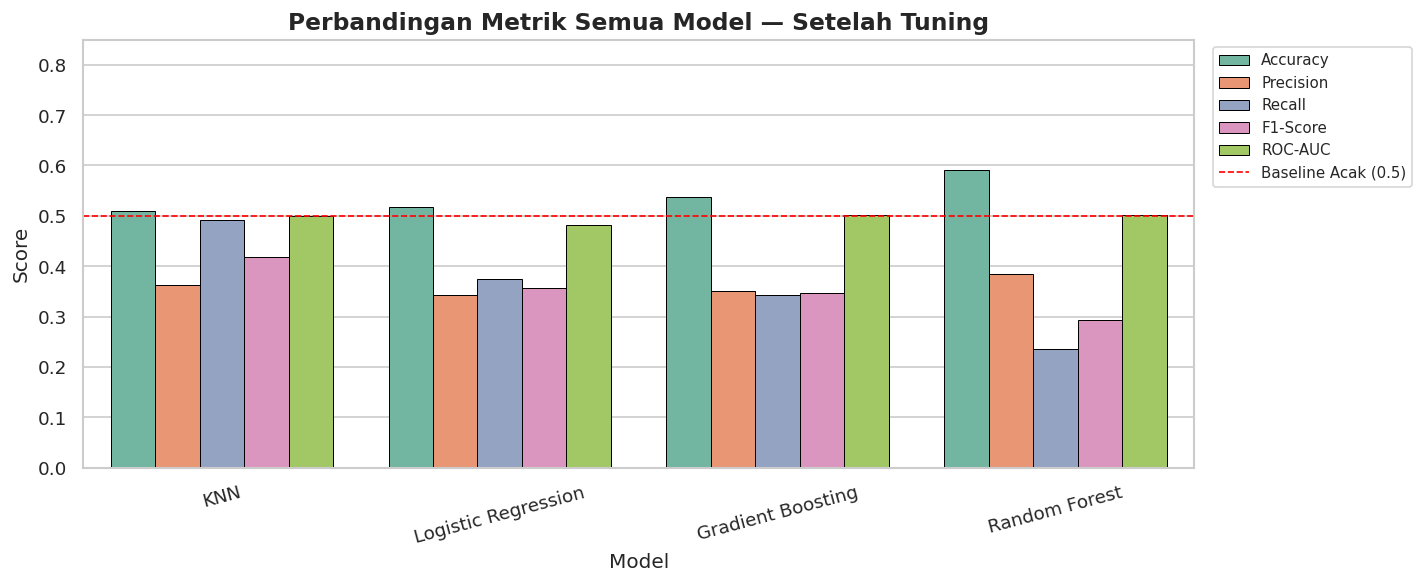

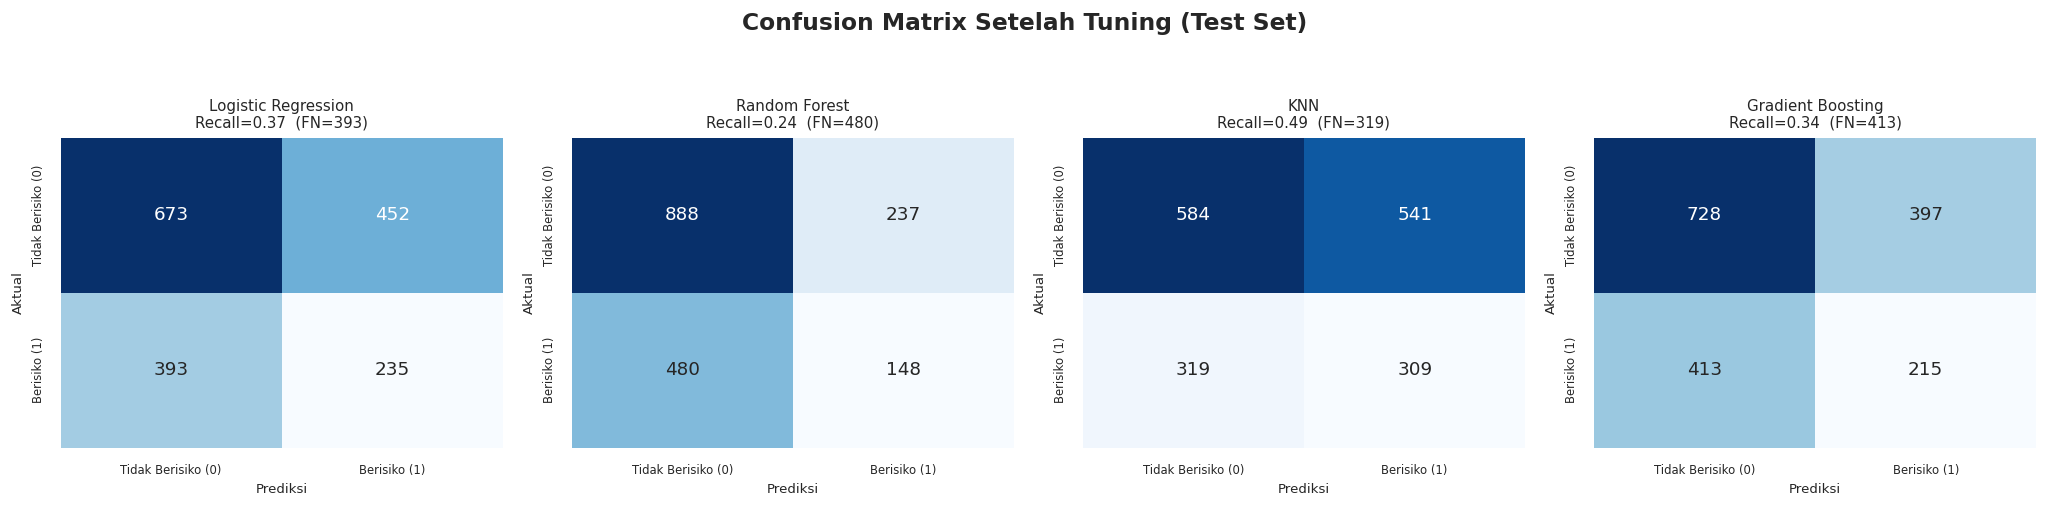

In [53]:
# Visualisasi: Bar Chart Metrik & Confusion Matrix (Heatmap)
metric_cols = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']

# 1) Bar chart perbandingan semua metrik per model (setelah tuning)
df_melt_tuned = df_tuned.melt(id_vars='Model', value_vars=metric_cols,
                              var_name='Metric', value_name='Score')

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=df_melt_tuned, x='Model', y='Score', hue='Metric',
            palette='Set2', edgecolor='black', linewidth=0.6, ax=ax)
ax.set_ylim(0, 0.85)
ax.axhline(0.5, color='red', linestyle='--', linewidth=1, label='Baseline Acak (0.5)')
ax.set_title('Perbandingan Metrik Semua Model — Setelah Tuning',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# 2) Confusion Matrix tiap model (tuned) sebagai heatmap
CLASS_LABELS = ['Tidak Berisiko (0)', 'Berisiko (1)']
n_models = len(tuned_models)

fig, axes = plt.subplots(1, n_models, figsize=(4.3 * n_models, 4))
axes = np.atleast_1d(axes)   # aman bila hanya 1 model
fig.suptitle('Confusion Matrix Setelah Tuning (Test Set)',
             fontsize=14, fontweight='bold', y=1.05)

for ax, (nama, model) in zip(axes, tuned_models.items()):
    cm = confusion_matrix(y_test, model.predict(X_test))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=CLASS_LABELS, yticklabels=CLASS_LABELS, ax=ax)
    tn, fp, fn, tp = cm.ravel()
    recall_i = tp / (tp + fn) if (tp + fn) else 0
    ax.set_title(f'{nama}\nRecall={recall_i:.2f}  (FN={fn})', fontsize=9)
    ax.set_xlabel('Prediksi', fontsize=8)
    ax.set_ylabel('Aktual', fontsize=8)
    ax.tick_params(labelsize=7)

plt.tight_layout()
plt.show()

## 3.5 ROC Curve & Precision-Recall Curve

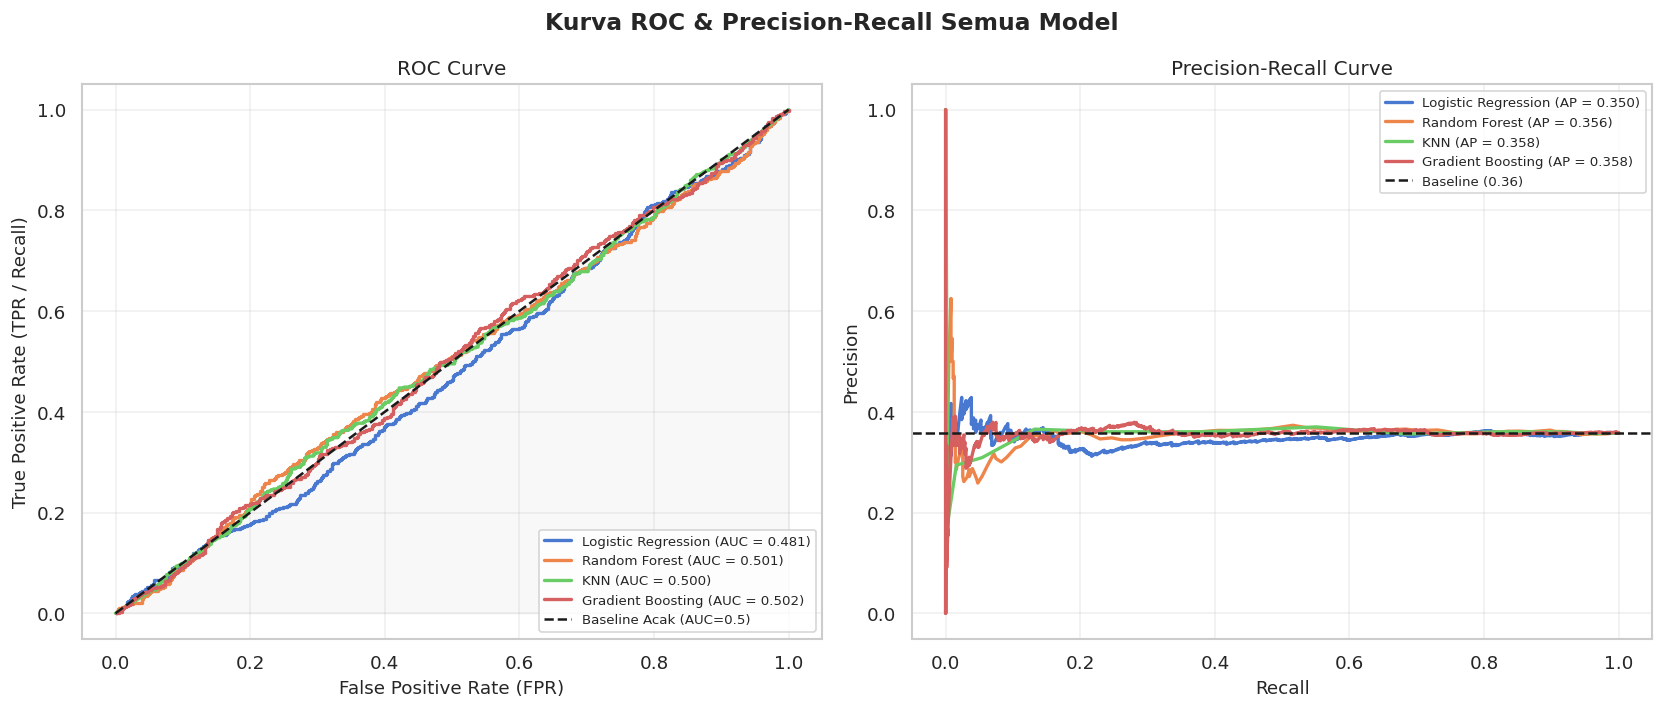

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Kurva ROC & Precision-Recall Semua Model', fontsize=14, fontweight='bold')

# Subplot 1: ROC Curve
ax1 = axes[0]
for name, model in tuned_models.items():
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    ax1.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {auc:.3f})')

ax1.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Baseline Acak (AUC=0.5)')
ax1.fill_between([0, 1], [0, 1], alpha=0.05, color='gray')
ax1.set_xlabel('False Positive Rate (FPR)', fontsize=11)
ax1.set_ylabel('True Positive Rate (TPR / Recall)', fontsize=11)
ax1.set_title('ROC Curve', fontsize=12)
ax1.legend(loc='lower right', fontsize=8)
ax1.grid(alpha=0.3)

# Subplot 2: Precision-Recall Curve
ax2 = axes[1]
baseline_pr = y_test.mean()  # proporsi kelas positif
for name, model in trained_models.items():
    y_proba = model.predict_proba(X_test)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    ap = average_precision_score(y_test, y_proba)
    ax2.plot(recall, precision, lw=2, label=f'{name} (AP = {ap:.3f})')

ax2.axhline(baseline_pr, color='k', linestyle='--', lw=1.5, label=f'Baseline ({baseline_pr:.2f})')
ax2.set_xlabel('Recall', fontsize=11)
ax2.set_ylabel('Precision', fontsize=11)
ax2.set_title('Precision-Recall Curve', fontsize=12)
ax2.legend(loc='upper right', fontsize=8)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Nilai ROC-AUC seluruh model berada di kisaran 0.49–0.51, mendekati garis baseline acak (0.5). Ini menunjukkan bahwa fitur-fitur dalam dataset, seperti usia, kolesterol, BMI, dan kebiasaan hidup tidak memiliki hubungan prediktif yang cukup kuat secara individual terhadap risiko serangan jantung. Keterbatasan ini bukan disebabkan oleh pemilihan algoritma, melainkan oleh sifat data itu sendiri, yang merupakan dataset sintetis.


## 3.6 Threshold Analysis

In [ ]:
# Dalam konteks medis, False Negative (pasien berisiko tidak terdeteksi)
# lebih berbahaya dari False Positive.
# Kita turunkan threshold untuk meningkatkan Recall.

MODEL_FOR_THRESHOLD = 'Logistic Regression'   # model dengan recall terbaik
model_thr = trained_models[MODEL_FOR_THRESHOLD]
y_proba_thr = model_thr.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.2, 0.8, 0.05)
thr_data = []
for thr in thresholds:
    y_pred_thr = (y_proba_thr >= thr).astype(int)
    thr_data.append({
        'Threshold': round(thr, 2),
        'Precision': round(precision_score(y_test, y_pred_thr, zero_division=0), 4),
        'Recall'   : round(recall_score(y_test, y_pred_thr, zero_division=0), 4),
        'F1-Score' : round(f1_score(y_test, y_pred_thr, zero_division=0), 4),
        'Accuracy' : round(accuracy_score(y_test, y_pred_thr), 4),
    })

df_thr = pd.DataFrame(thr_data)
print(f'Analisis Threshold — {MODEL_FOR_THRESHOLD}')
print(df_thr.to_string(index=False))

Analisis Threshold — Logistic Regression
 Threshold  Precision  Recall  F1-Score  Accuracy
      0.20     0.3579  0.9984    0.5269    0.3577
      0.25     0.3585  0.9889    0.5263    0.3622
      0.30     0.3534  0.9363    0.5131    0.3634
      0.35     0.3547  0.8551    0.5014    0.3908
      0.40     0.3562  0.7197    0.4765    0.4335
      0.45     0.3463  0.5398    0.4219    0.4701
      0.50     0.3411  0.3726    0.3562    0.5174
      0.55     0.3168  0.2134    0.2550    0.5533
      0.60     0.3607  0.1258    0.1865    0.6070
      0.65     0.3663  0.0589    0.1015    0.6264
      0.70     0.3571  0.0159    0.0305    0.6372
      0.75     0.2500  0.0016    0.0032    0.6406
      0.80     0.0000  0.0000    0.0000    0.6418


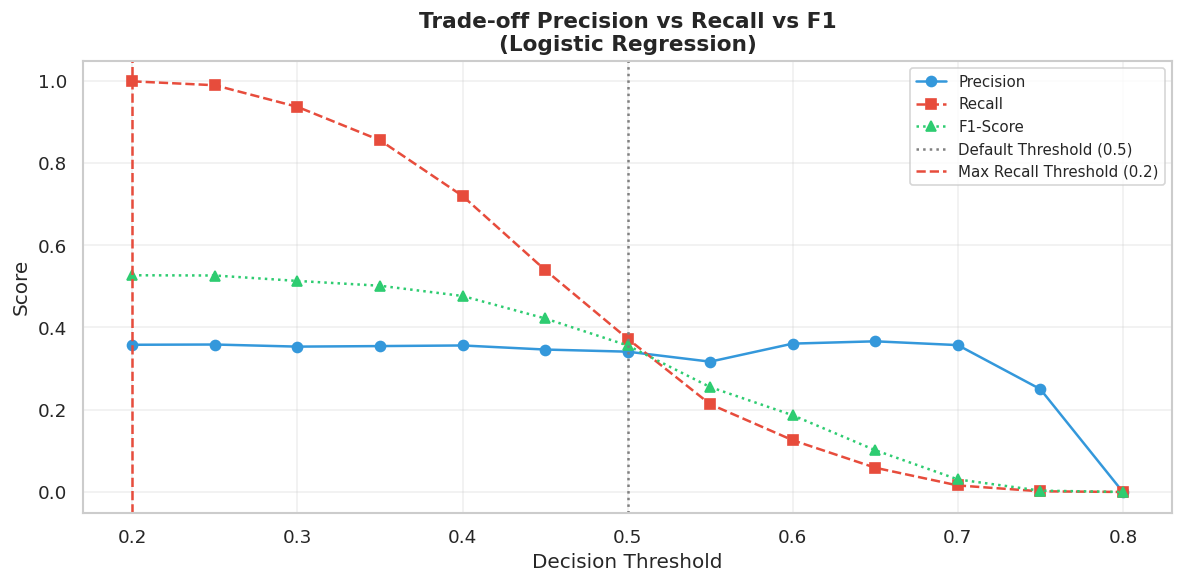

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df_thr['Threshold'], df_thr['Precision'], 'o-', color='#3498db', label='Precision')
ax.plot(df_thr['Threshold'], df_thr['Recall'],    's--', color='#e74c3c', label='Recall')
ax.plot(df_thr['Threshold'], df_thr['F1-Score'],  '^:', color='#2ecc71', label='F1-Score')
ax.axvline(0.5, color='gray', linestyle=':', lw=1.5, label='Default Threshold (0.5)')
ax.set_xlabel('Decision Threshold', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title(f'Trade-off Precision vs Recall vs F1\n({MODEL_FOR_THRESHOLD})',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

# Tandai threshold optimal untuk recall
best_recall_idx = df_thr['Recall'].idxmax()
best_thr_recall = df_thr.loc[best_recall_idx, 'Threshold']
ax.axvline(best_thr_recall, color='#e74c3c', linestyle='--', lw=1.5,
           label=f'Max Recall Threshold ({best_thr_recall})')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

Dalam konteks medis, menurunkan decision threshold di bawah 0.5 meningkatkan Recall (lebih banyak pasien berisiko terdeteksi) dengan konsekuensi turunnya Precision (lebih banyak false alarm). Trade-off ini dapat diterima dalam aplikasi prediksi serangan jantung, karena konsekuensi melewatkan pasien berisiko jauh lebih serius dibandingkan memberikan peringatan yang tidak perlu. Model yang dipilih untuk deployment adalah Logistic Regression dengan threshold yang dioptimalkan untuk memaksimalkan Recall.

## 3.7 Feature Importance

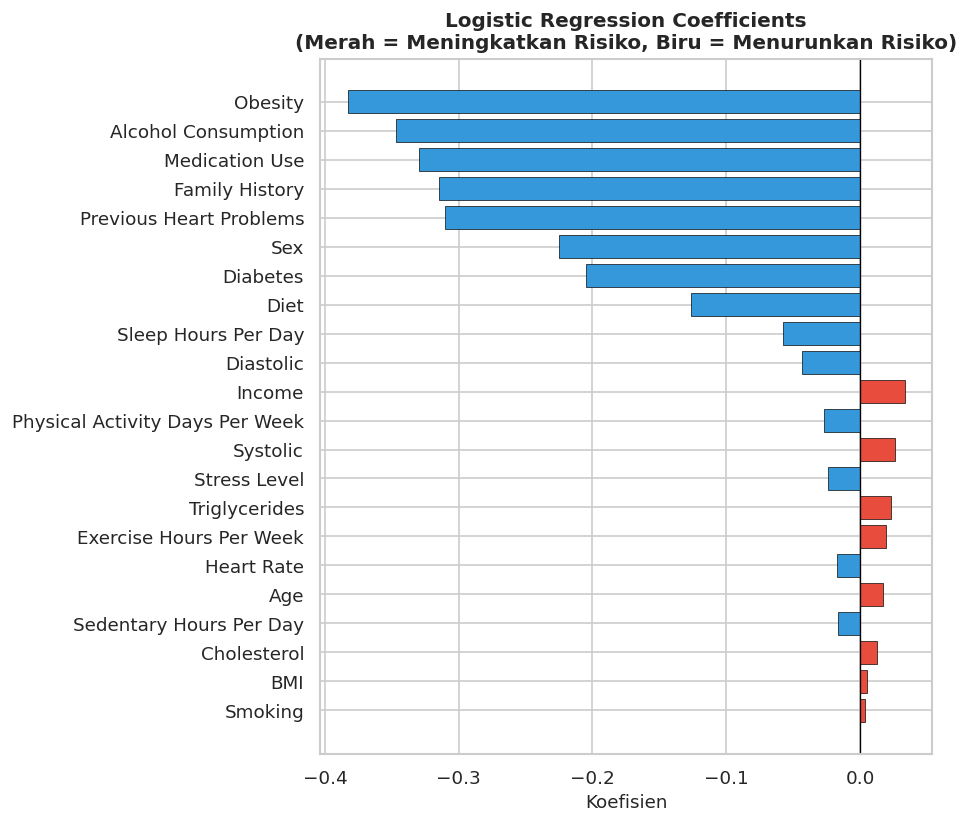

In [ ]:
# Logistic Regression Coefficients
lr = trained_models['Logistic Regression']
coef_df = pd.DataFrame({
    'Feature'    : X_train.columns,
    'Coefficient': lr.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=True)

colors = ['#e74c3c' if c > 0 else '#3498db' for c in coef_df['Coefficient']]

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, edgecolor='black', linewidth=0.4)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Logistic Regression Coefficients\n(Merah = Meningkatkan Risiko, Biru = Menurunkan Risiko)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Koefisien', fontsize=11)
plt.tight_layout()
plt.show()